In [2]:
import pandas as pd

credit = pd.read_csv("data/credit_final.csv")
credit = credit.rename(columns={"age_groups_60+": "age_groups_60_plus",
                                "age_groups_<30": "age_groups_less_than_30"})

## Podział zbioru danych

In [3]:
from sklearn.model_selection import train_test_split

X = credit.drop(columns="risk")
y = credit["risk"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
y.value_counts(normalize=True)

risk
1    0.7
0    0.3
Name: proportion, dtype: float64

In [6]:
y_train.value_counts(normalize=True)

risk
1    0.69875
0    0.30125
Name: proportion, dtype: float64

In [7]:
y_test.value_counts(normalize=True)

risk
1    0.705
0    0.295
Name: proportion, dtype: float64

# Drzewo decyzyjne

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf_tree = DecisionTreeClassifier(random_state=42, max_depth=3)
clf_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

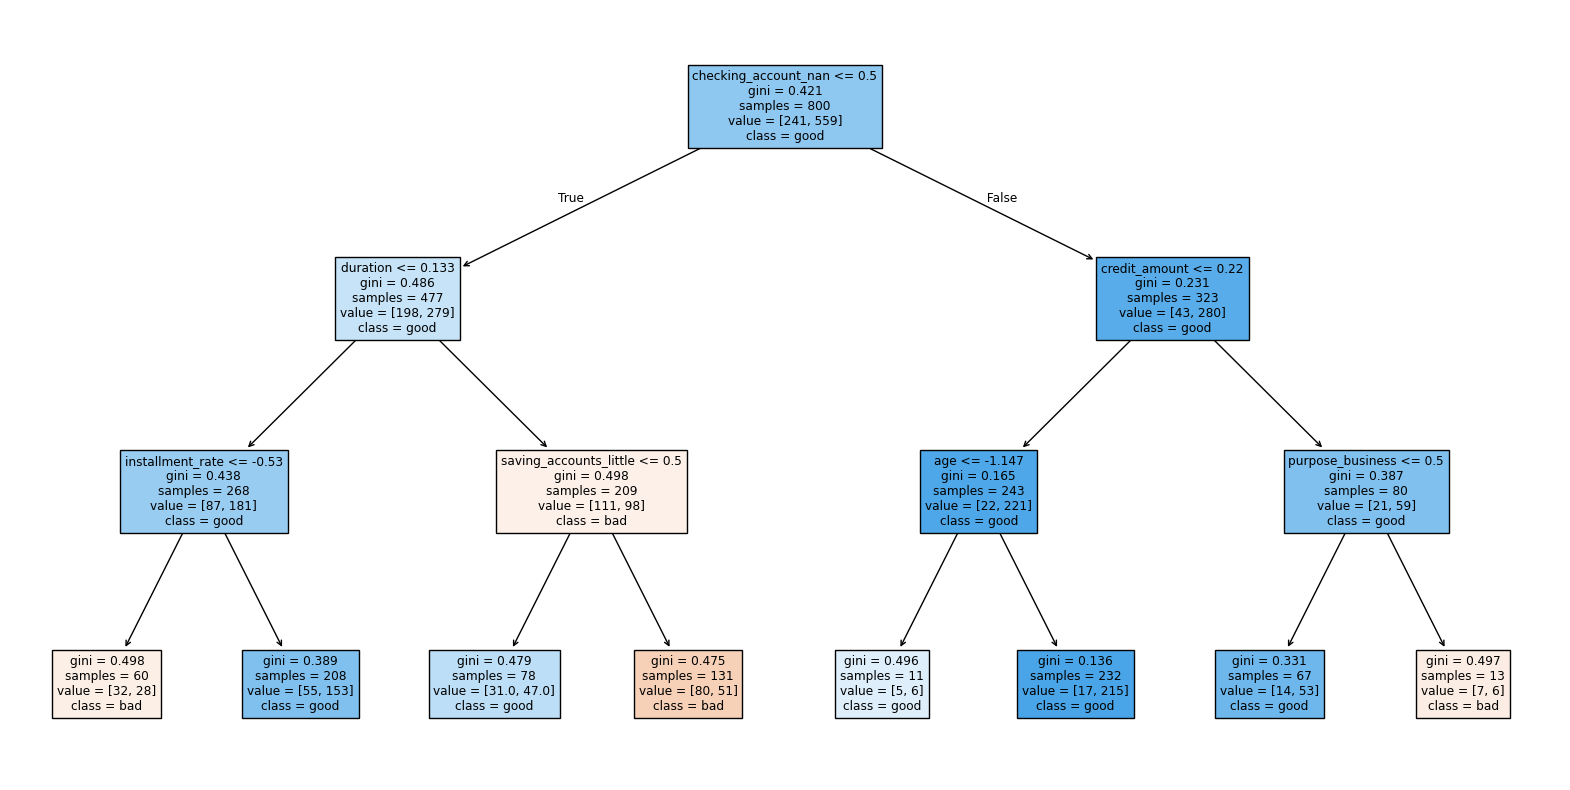

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf_tree, filled=True, feature_names=X.columns, class_names=["bad", "good"])
plt.show()

In [14]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, balanced_accuracy_score)

y_pred_train_tree = clf_tree.predict(X_train)
confusion_matrix(y_train, y_pred_train_tree)

array([[119, 122],
       [ 85, 474]])

In [15]:
print(classification_report(y_train, y_pred_train_tree))

              precision    recall  f1-score   support

           0       0.58      0.49      0.53       241
           1       0.80      0.85      0.82       559

    accuracy                           0.74       800
   macro avg       0.69      0.67      0.68       800
weighted avg       0.73      0.74      0.73       800



In [16]:
def evaluate_model(y_true, y_pred):

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    specificity = tn / (tn + fp)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")

In [17]:
evaluate_model(y_train, y_pred_train_tree)

Confusion Matrix:
[[119 122]
 [ 85 474]]
Accuracy: 0.7412
Balanced Accuracy: 0.6709
Precision: 0.7953
Recall: 0.8479
F1 Score: 0.8208
Specificity: 0.4938


In [18]:
y_pred_test_tree = clf_tree.predict(X_test)
evaluate_model(y_test, y_pred_test_tree)

Confusion Matrix:
[[ 36  23]
 [ 24 117]]
Accuracy: 0.7650
Balanced Accuracy: 0.7200
Precision: 0.8357
Recall: 0.8298
F1 Score: 0.8327
Specificity: 0.6102


Accuracy = 0,76 = 76% dokładności modelu

Balanced accuracy = 0,72 = 72% trafności modelu uwzględniając nierównowagę klas

Precision (precyzja) = 0,83 = 83% klientów zaklasyfikowanych jako dobrzy klienci to rzeczywiście dobrzy klienci

Recall (czułość) = 0,83 = 83% - udaje się modelowi zaklasyfikować 83% dobrych klientów, a 17% klasyfikuje jako złych

Specificity (swoistość) = 0,61 = 61% złych klientów zostało poprawnie rozpoznanych, a 39% złych klientów jest klasyfikowanych jako dobrzy klienci

F1 = 0,83 = 83% skuteczności modelu dla klasy dobrzy klienci

AUC: 0.7876


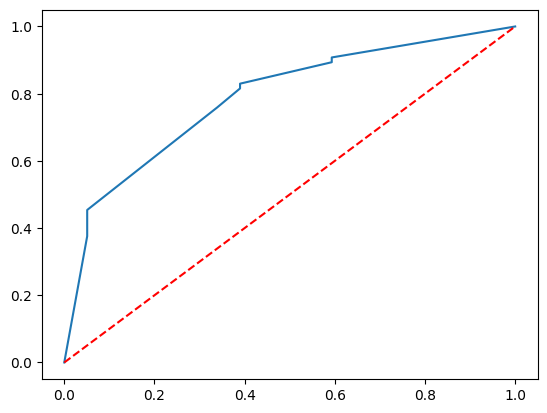

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba_test_tree = clf_tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test_tree)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--", color="red")
print(f"AUC: {roc_auc_score(y_test, y_proba_test_tree):.4f}")

In [22]:
def roc_plot(y_true, X, model):
    y_pred_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--', color='red')
    print(f"AUC: {roc_auc_score(y_true, y_pred_proba):.4f}")

AUC: 0.7876


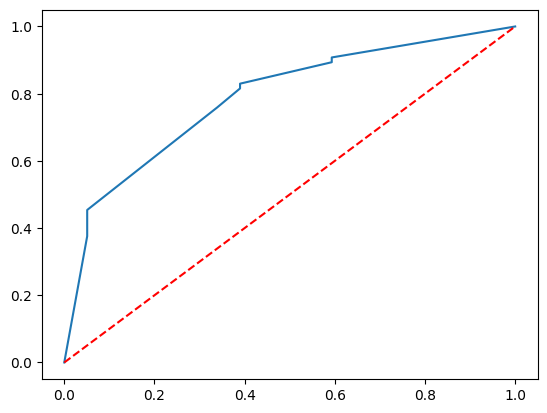

In [23]:
roc_plot(y_test, X_test, clf_tree)

# SVM

In [33]:
from sklearn.svm import SVC

# clf_svm = SVC(random_state=42, probability=True, kernel="linear")
clf_svm = SVC(random_state=42, probability=True, kernel="poly")
# clf_svm = SVC(random_state=42, probability=True, kernel="rbf")
clf_svm.fit(X_train, y_train)

y_pred_train_svm = clf_svm.predict(X_train)
y_pred_test_svm = clf_svm.predict(X_test)

In [34]:
evaluate_model(y_train, y_pred_train_svm)

Confusion Matrix:
[[128 113]
 [ 14 545]]
Accuracy: 0.8413
Balanced Accuracy: 0.7530
Precision: 0.8283
Recall: 0.9750
F1 Score: 0.8956
Specificity: 0.5311


In [35]:
evaluate_model(y_test, y_pred_test_svm)

Confusion Matrix:
[[ 21  38]
 [ 10 131]]
Accuracy: 0.7600
Balanced Accuracy: 0.6425
Precision: 0.7751
Recall: 0.9291
F1 Score: 0.8452
Specificity: 0.3559


AUC: 0.7578


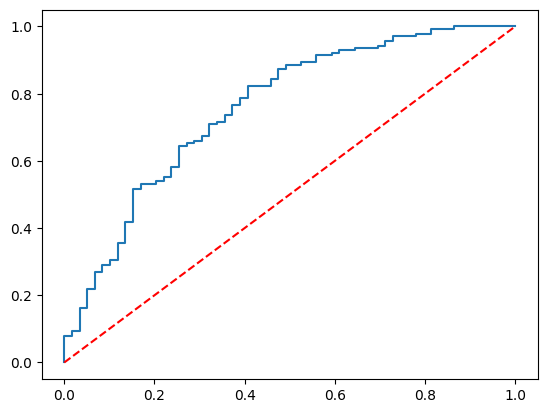

In [36]:
roc_plot(y_test, X_test, clf_svm)

# Lasy losowe

In [43]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=7)
clf_rf.fit(X_train, y_train)

y_pred_train_rf = clf_rf.predict(X_train)
y_pred_test_rf = clf_rf.predict(X_test)

In [44]:
evaluate_model(y_train, y_pred_train_rf)

Confusion Matrix:
[[133 108]
 [  3 556]]
Accuracy: 0.8612
Balanced Accuracy: 0.7733
Precision: 0.8373
Recall: 0.9946
F1 Score: 0.9092
Specificity: 0.5519


In [45]:
evaluate_model(y_test, y_pred_test_rf)

Confusion Matrix:
[[ 16  43]
 [  7 134]]
Accuracy: 0.7500
Balanced Accuracy: 0.6108
Precision: 0.7571
Recall: 0.9504
F1 Score: 0.8428
Specificity: 0.2712


AUC: 0.7931


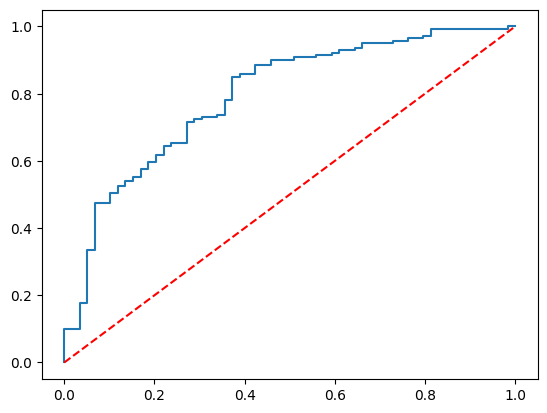

In [46]:
roc_plot(y_test, X_test, clf_rf)

# Boosting gradientowy

In [54]:
from sklearn.ensemble import GradientBoostingClassifier

clf_gb = GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=3)
clf_gb.fit(X_train, y_train)

y_pred_train_gb = clf_gb.predict(X_train)
y_pred_test_gb = clf_gb.predict(X_test)

In [55]:
evaluate_model(y_train, y_pred_train_gb)

Confusion Matrix:
[[164  77]
 [ 16 543]]
Accuracy: 0.8838
Balanced Accuracy: 0.8259
Precision: 0.8758
Recall: 0.9714
F1 Score: 0.9211
Specificity: 0.6805


In [56]:
evaluate_model(y_test, y_pred_test_gb)

Confusion Matrix:
[[ 25  34]
 [  9 132]]
Accuracy: 0.7850
Balanced Accuracy: 0.6799
Precision: 0.7952
Recall: 0.9362
F1 Score: 0.8599
Specificity: 0.4237


AUC: 0.8119


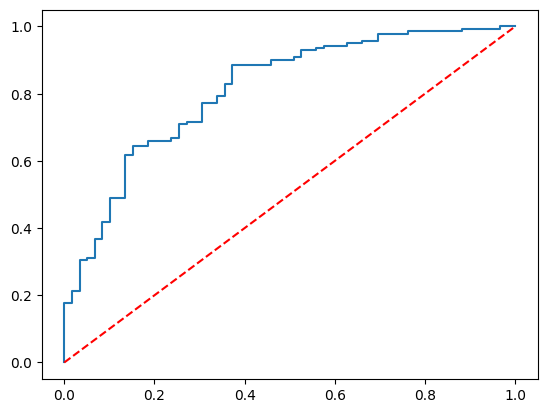

In [57]:
roc_plot(y_test, X_test, clf_gb)

In [58]:
! pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
from xgboost import XGBClassifier

clf_xgb = XGBClassifier(random_state=42, n_estimators=100, max_depth=3)
clf_xgb.fit(X_train, y_train)

y_pred_train_xgb = clf_xgb.predict(X_train)
y_pred_test_xgb = clf_xgb.predict(X_test)

In [60]:
evaluate_model(y_train, y_pred_train_xgb)

Confusion Matrix:
[[198  43]
 [  5 554]]
Accuracy: 0.9400
Balanced Accuracy: 0.9063
Precision: 0.9280
Recall: 0.9911
F1 Score: 0.9585
Specificity: 0.8216


In [61]:
evaluate_model(y_test, y_pred_test_xgb)

Confusion Matrix:
[[ 29  30]
 [ 14 127]]
Accuracy: 0.7800
Balanced Accuracy: 0.6961
Precision: 0.8089
Recall: 0.9007
F1 Score: 0.8523
Specificity: 0.4915


AUC: 0.7850


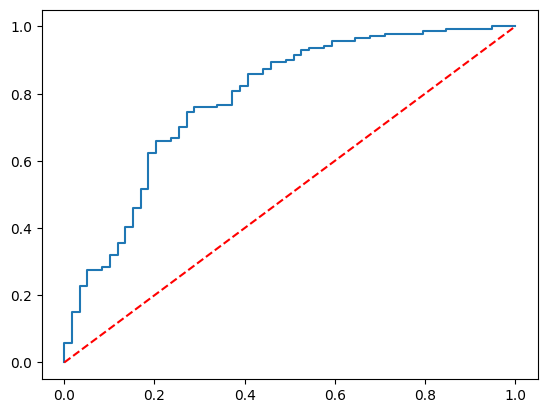

In [62]:
roc_plot(y_test, X_test, clf_xgb)

# Walidacja krzyżowa

In [63]:
from sklearn.model_selection import cross_val_score

scores_cv = cross_val_score(clf_xgb, X_train, y_train, cv=5, scoring="roc_auc")
print(f"Cross-validated AUC scores: {scores_cv}")

Cross-validated AUC scores: [0.72421401 0.72767857 0.68024554 0.74497768 0.76023065]


In [64]:
print(scores_cv.mean())

0.7274692900808971


# Ważność cech

In [65]:
clf_xgb.feature_importances_

array([0.02819066, 0.02772985, 0.03240392, 0.03020962, 0.03264984,
       0.        , 0.        , 0.02232248, 0.03503082, 0.0380832 ,
       0.02090283, 0.03443429, 0.0365106 , 0.04137734, 0.01901928,
       0.        , 0.03438519, 0.05291465, 0.06004363, 0.02506951,
       0.0171733 , 0.19007026, 0.04448954, 0.032022  , 0.        ,
       0.02302361, 0.02855533, 0.03206354, 0.01342535, 0.00673745,
       0.02663918, 0.01452276, 0.        , 0.        ], dtype=float32)

In [66]:
fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": clf_xgb.feature_importances_
}).sort_values(by="importance", ascending=False)
fi_df

,feature,importance
21,checking_account_nan,0.190070
18,checking_account_little,0.060044
17,saving_accounts_nan,0.052915
22,purpose_business,0.044490
13,saving_accounts_little,0.041377
9,job_3,0.038083
12,housing_rent,0.036511
8,job_2,0.035031
11,housing_own,0.034434
16,saving_accounts_rich,0.034385


In [ ]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(clf_xgb, X_test, y_test, n_repeats=30, random_state=42)


In [68]:
perm_importance.importances_mean

array([ 0.01033333,  0.0335    ,  0.02983333,  0.0425    , -0.00766667,
        0.        ,  0.        , -0.00933333,  0.0075    ,  0.005     ,
        0.00066667,  0.00166667,  0.        ,  0.00566667, -0.00033333,
        0.        ,  0.007     ,  0.01      ,  0.02      , -0.00316667,
       -0.00066667,  0.042     , -0.00333333, -0.00116667,  0.        ,
        0.0085    , -0.0035    , -0.00783333,  0.00033333, -0.00016667,
        0.0025    , -0.00133333,  0.        ,  0.        ])

In [69]:
fi_df_perm = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean
}).sort_values(by="importance", ascending=False)
fi_df_perm

,feature,importance
3,installment_rate,0.042500
21,checking_account_nan,0.042000
1,credit_amount,0.033500
2,duration,0.029833
18,checking_account_little,0.020000
0,age,0.010333
17,saving_accounts_nan,0.010000
25,purpose_education,0.008500
8,job_2,0.007500
16,saving_accounts_rich,0.007000
